Lyapunov exponents (sorted): [-0.01498814 -0.01501922 -0.07581636]
Kaplan–Yorke dimension: 0.0


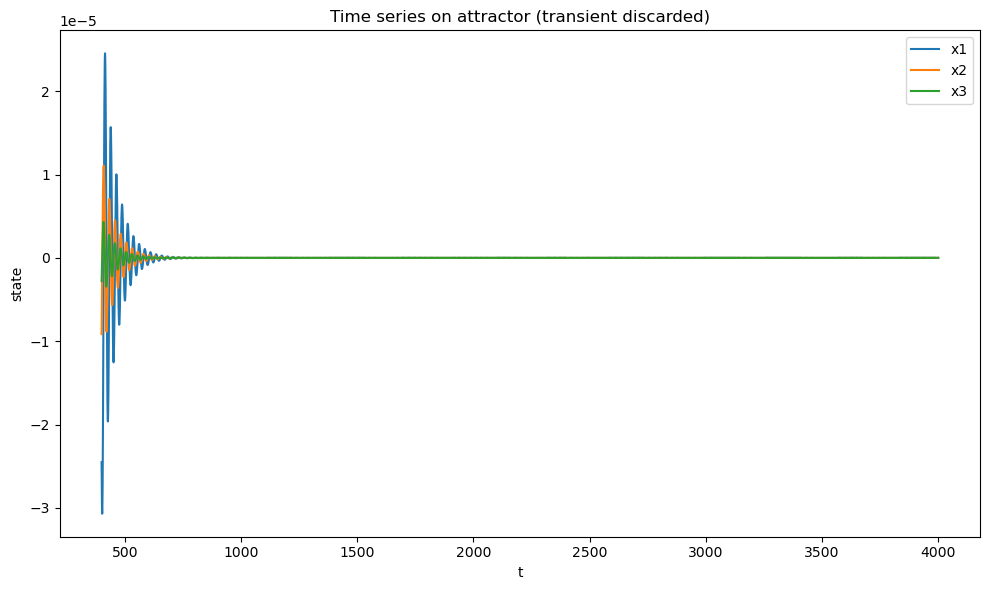

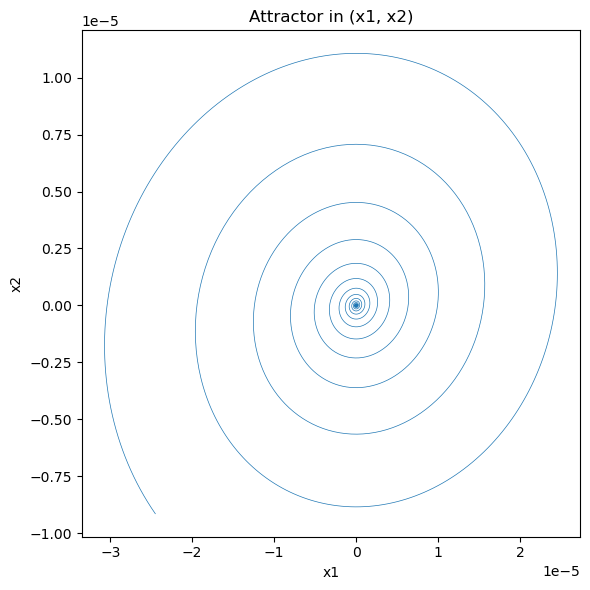

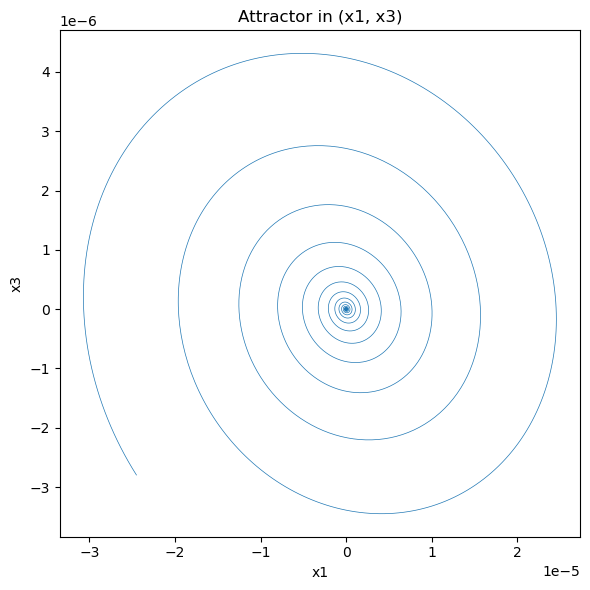

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -----------------------------
# Parameters and system definition
# -----------------------------

beta1 = 1.0
beta2 = 0.84
rho = 0.048
kappa_prime = 0.8544
v0 = 1.0  # usually taken as 1 in these nondimensional forms; adjust if specified otherwise

# Critical kappas and final kappa
kappa_cr1 = beta1 - 1.0

# From the given expression:
# κ(2)_cr = κ(1)_cr + ρ [2β1 + (β2 − 1)(2 + ρ)] +
#          sqrt( 4ρ^2(κ(1)_cr + β2) + [κ(1)_cr + ρ^2(β2 − 1)]^2 ) / (2(1 + ρ))
term_inside_sqrt = 4 * rho**2 * (kappa_cr1 + beta2) + (kappa_cr1 + rho**2 * (beta2 - 1.0))**2
kappa_cr2 = (
    kappa_cr1
    + rho * (2 * beta1 + (beta2 - 1.0) * (2 + rho))
    + np.sqrt(term_inside_sqrt) / (2 * (1 + rho))
)

kappa = kappa_cr2 * kappa_prime

def spring_slider_rhs(t, x):
    """
    x = [x1, x2, x3]
    """
    x1, x2, x3 = x
    e = np.exp(x1)

    f1 = -kappa * (e - v0) + e * (x1 * (beta1 - 1.0) + x2 - x3) + rho * e * (beta2 * x1 + x3)
    f2 = -kappa * (e - v0)
    f3 = -rho * e * (beta2 * x1 + x3)

    return np.array([f1, f2, f3])

def jacobian(x):
    """
    Jacobian Jf(x) of the RHS with respect to x = [x1, x2, x3].
    """
    x1, x2, x3 = x
    e = np.exp(x1)

    # df1/dx1
    df1_dx1 = (
        -kappa * e
        + e * (x1 * (beta1 - 1.0) + x2 - x3 + (beta1 - 1.0))
        + rho * e * (beta2 * x1 + x3 + beta2)
    )
    # df1/dx2
    df1_dx2 = e
    # df1/dx3
    df1_dx3 = e * (-1.0 + rho)

    # df2/dx1
    df2_dx1 = -kappa * e
    df2_dx2 = 0.0
    df2_dx3 = 0.0

    # df3/dx1
    df3_dx1 = -rho * e * (beta2 * x1 + x3 + beta2)
    df3_dx2 = 0.0
    df3_dx3 = -rho * e

    J = np.array([
        [df1_dx1, df1_dx2, df1_dx3],
        [df2_dx1, df2_dx2, df2_dx3],
        [df3_dx1, df3_dx2, df3_dx3],
    ])
    return J

# -----------------------------
# Integrate the system
# -----------------------------

t_start = 0.0
t_end = 4000.0
dt = 0.1
t_eval = np.arange(t_start, t_end + dt, dt)

x0 = np.array([0.05, 0.0, 0.0])

sol = solve_ivp(
    spring_slider_rhs,
    (t_start, t_end),
    x0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-9,
)

t = sol.t
X = sol.y.T  # shape (N, 3)

# Discard transient
t_transient = 400.0
mask_attractor = t >= t_transient
t_attr = t[mask_attractor]
X_attr = X[mask_attractor]

# -----------------------------
# Lyapunov spectrum via QR
# -----------------------------

n = 3
N = len(t)
V = np.eye(n)  # initial orthonormal basis

sum_logs = np.zeros(n)
started = False

for k in range(N - 1):
    xk = X[k]
    J = jacobian(xk)
    # Linear operator A(t) = I + J dt
    A = np.eye(n) + J * dt
    V = A @ V
    # QR orthonormalization
    Q, R = np.linalg.qr(V)
    V = Q

    # Only accumulate after transient
    if t[k] >= t_transient:
        diag_R = np.diag(R)
        sum_logs += np.log(np.abs(diag_R))
        started = True

if not started:
    raise RuntimeError("Transient time too long; no data left for Lyapunov calculation.")

T_lyap = t_end - t_transient
lambdas = sum_logs / T_lyap

# Sort Lyapunov exponents in descending order (standard convention)
lambdas_sorted = np.sort(lambdas)[::-1]

# -----------------------------
# Kaplan–Yorke dimension
# -----------------------------

def kaplan_yorke_dimension(lams):
    cumsum = np.cumsum(lams)
    j = None
    for i in range(len(lams)):
        if cumsum[i] >= 0:
            j = i
        else:
            break
    if j is None:
        # all sums negative -> dimension 0
        return 0.0
    if j == len(lams) - 1:
        # all sums non-negative -> dimension is full dimension
        return float(len(lams))
    return j + 1 + cumsum[j] / abs(lams[j + 1])

D_KY = kaplan_yorke_dimension(lambdas_sorted)

print("Lyapunov exponents (sorted):", lambdas_sorted)
print("Kaplan–Yorke dimension:", D_KY)

# -----------------------------
# Plots: time series and attractor
# -----------------------------

plt.figure(figsize=(10, 6))
plt.plot(t_attr, X_attr[:, 0], label="x1")
plt.plot(t_attr, X_attr[:, 1], label="x2")
plt.plot(t_attr, X_attr[:, 2], label="x3")
plt.xlabel("t")
plt.ylabel("state")
plt.title("Time series on attractor (transient discarded)")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(6, 6))
plt.plot(X_attr[:, 0], X_attr[:, 1], lw=0.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Attractor in (x1, x2)")
plt.tight_layout()

plt.figure(figsize=(6, 6))
plt.plot(X_attr[:, 0], X_attr[:, 2], lw=0.5)
plt.xlabel("x1")
plt.ylabel("x3")
plt.title("Attractor in (x1, x3)")
plt.tight_layout()

plt.show()

Lyapunov exponents (sorted): [-0.01498814 -0.01501922 -0.07581636]
Kaplan–Yorke dimension D_KY: 0.0
Theiler window (first zero of autocorr): 61
Correlation dimension with Theiler window D_corr: 0.17310590452641908
Correlation dimension without Theiler window D_corr: 0.17560908202504308


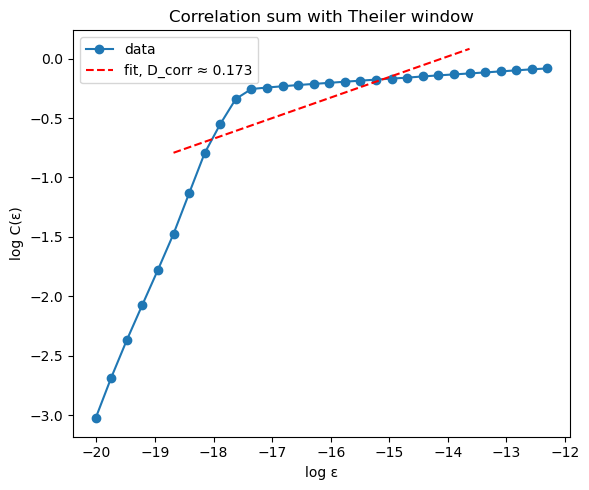

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.spatial.distance import pdist, squareform
from scipy.signal import correlate
import matplotlib.pyplot as plt

# ============================================================
# 1. System definition (same as Practical 1)
# ============================================================

beta1 = 1.0
beta2 = 0.84
rho = 0.048
kappa_prime = 0.8544
v0 = 1.0  # if your practical specifies a different v0, change here

kappa_cr1 = beta1 - 1.0

term_inside_sqrt = (
    4 * rho**2 * (kappa_cr1 + beta2)
    + (kappa_cr1 + rho**2 * (beta2 - 1.0))**2
)
kappa_cr2 = (
    kappa_cr1
    + rho * (2 * beta1 + (beta2 - 1.0) * (2 + rho))
    + np.sqrt(term_inside_sqrt) / (2 * (1 + rho))
)

kappa = kappa_cr2 * kappa_prime

def spring_slider_rhs(t, x):
    x1, x2, x3 = x
    e = np.exp(x1)

    f1 = -kappa * (e - v0) + e * (x1 * (beta1 - 1.0) + x2 - x3) + rho * e * (beta2 * x1 + x3)
    f2 = -kappa * (e - v0)
    f3 = -rho * e * (beta2 * x1 + x3)

    return np.array([f1, f2, f3])

def jacobian(x):
    x1, x2, x3 = x
    e = np.exp(x1)

    df1_dx1 = (
        -kappa * e
        + e * (x1 * (beta1 - 1.0) + x2 - x3 + (beta1 - 1.0))
        + rho * e * (beta2 * x1 + x3 + beta2)
    )
    df1_dx2 = e
    df1_dx3 = e * (-1.0 + rho)

    df2_dx1 = -kappa * e
    df2_dx2 = 0.0
    df2_dx3 = 0.0

    df3_dx1 = -rho * e * (beta2 * x1 + x3 + beta2)
    df3_dx2 = 0.0
    df3_dx3 = -rho * e

    J = np.array([
        [df1_dx1, df1_dx2, df1_dx3],
        [df2_dx1, df2_dx2, df2_dx3],
        [df3_dx1, df3_dx2, df3_dx3],
    ])
    return J

# ============================================================
# 2. Integrate system and compute Lyapunov spectrum + DKY
# ============================================================

def integrate_system(t_end=4000.0, dt=0.1, t_transient=400.0):
    t_start = 0.0
    t_eval = np.arange(t_start, t_end + dt, dt)
    x0 = np.array([0.05, 0.0, 0.0])

    sol = solve_ivp(
        spring_slider_rhs,
        (t_start, t_end),
        x0,
        t_eval=t_eval,
        method="RK45",
        rtol=1e-9,
        atol=1e-9,
    )

    t = sol.t
    X = sol.y.T  # (N, 3)

    mask_attr = t >= t_transient
    t_attr = t[mask_attr]
    X_attr = X[mask_attr]

    return t, X, t_attr, X_attr, dt, t_transient, t_end

def lyapunov_spectrum(t, X, dt, t_transient, t_end):
    n = 3
    N = len(t)
    V = np.eye(n)
    sum_logs = np.zeros(n)
    started = False

    for k in range(N - 1):
        xk = X[k]
        J = jacobian(xk)
        A = np.eye(n) + J * dt
        V = A @ V
        Q, R = np.linalg.qr(V)
        V = Q

        if t[k] >= t_transient:
            diag_R = np.diag(R)
            sum_logs += np.log(np.abs(diag_R))
            started = True

    if not started:
        raise RuntimeError("Transient too long; no data for Lyapunov calculation.")

    T_lyap = t_end - t_transient
    lambdas = sum_logs / T_lyap
    lambdas_sorted = np.sort(lambdas)[::-1]
    return lambdas_sorted

def kaplan_yorke_dimension(lams):
    cumsum = np.cumsum(lams)
    j = None
    for i in range(len(lams)):
        if cumsum[i] >= 0:
            j = i
        else:
            break
    if j is None:
        return 0.0
    if j == len(lams) - 1:
        return float(len(lams))
    return j + 1 + cumsum[j] / abs(lams[j + 1])

# ============================================================
# 3. Correlation dimension
# ============================================================

def first_zero_autocorr(x):
    x = x - np.mean(x)
    ac = correlate(x, x, mode="full")
    ac = ac[ac.size // 2:]
    ac = ac / ac[0]
    for k in range(1, len(ac)):
        if ac[k] <= 0:
            return k
    return len(ac) - 1  # fallback if never crosses zero

def correlation_dimension(X_attr,
                          theiler_window=None,
                          max_points=4000,
                          n_eps=30,
                          fit_slice=(5, -5)):
    """
    X_attr: (N, d) trajectory on attractor
    theiler_window: integer lag to exclude |i-j| <= W, or None for no Theiler window
    max_points: subsample size for correlation sum
    """
    N = X_attr.shape[0]
    if N > max_points:
        idx = np.linspace(0, N - 1, max_points, dtype=int)
        Y = X_attr[idx]
    else:
        Y = X_attr
    M = Y.shape[0]

    # Pairwise distances
    D = squareform(pdist(Y, metric="euclidean"))

    # Mask for upper triangle and Theiler window
    idxs = np.arange(M)
    lag_mat = np.abs(idxs[:, None] - idxs[None, :])

    mask = np.triu(np.ones_like(D, dtype=bool), k=1)
    if theiler_window is not None and theiler_window > 0:
        mask &= (lag_mat > theiler_window)

    dists = D[mask]
    dists = dists[dists > 0]

    # Choose eps range from percentiles
    dmin = np.percentile(dists, 5)
    dmax = np.percentile(dists, 95)
    eps = np.logspace(np.log10(dmin), np.log10(dmax), n_eps)

    C = []
    norm = 2.0 / (M * (M - 1))
    for e in eps:
        C.append(norm * np.sum(dists < e))
    C = np.array(C)

    log_eps = np.log(eps)
    log_C = np.log(C)

    # Fit slope in scaling region
    i0, i1 = fit_slice
    if i1 <= 0:
        i1 = len(log_eps) + i1
    fit_mask = np.arange(len(log_eps))[i0:i1]
    slope, intercept = np.polyfit(log_eps[fit_mask], log_C[fit_mask], 1)

    return slope, eps, C, (log_eps, log_C, fit_mask)

# ============================================================
# 4. Run everything
# ============================================================

if __name__ == "__main__":
    # Integrate
    t, X, t_attr, X_attr, dt, t_transient, t_end = integrate_system()

    # Lyapunov + DKY
    lambdas = lyapunov_spectrum(t, X, dt, t_transient, t_end)
    D_KY = kaplan_yorke_dimension(lambdas)

    print("Lyapunov exponents (sorted):", lambdas)
    print("Kaplan–Yorke dimension D_KY:", D_KY)

    # Theiler window from first zero of autocorrelation of x1
    x1_attr = X_attr[:, 0]
    W = first_zero_autocorr(x1_attr)
    print("Theiler window (first zero of autocorr):", W)

    # Correlation dimension with Theiler window
    D_corr_theiler, eps, C, (log_eps, log_C, fit_mask) = correlation_dimension(
        X_attr, theiler_window=W
    )
    print("Correlation dimension with Theiler window D_corr:", D_corr_theiler)

    # Correlation dimension without Theiler window
    D_corr_no_theiler, eps2, C2, _ = correlation_dimension(
        X_attr, theiler_window=None
    )
    print("Correlation dimension without Theiler window D_corr:", D_corr_no_theiler)

    # Plot log C(eps) vs log eps and fitted line (with Theiler window)
    plt.figure(figsize=(6, 5))
    plt.plot(log_eps, log_C, "o-", label="data")
    slope = D_corr_theiler
    intercept = np.polyfit(log_eps[fit_mask], log_C[fit_mask], 1)[1]
    plt.plot(
        log_eps[fit_mask],
        slope * log_eps[fit_mask] + intercept,
        "r--",
        label=f"fit, D_corr ≈ {slope:.3f}",
    )
    plt.xlabel("log ε")
    plt.ylabel("log C(ε)")
    plt.title("Correlation sum with Theiler window")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # If you want to explore trajectory length and sampling rate:
    # - change t_end or dt in integrate_system()
    # - rerun and compare D_corr and D_KY

Theiler window = 61
Correlation dimension with Theiler window = 0.17310590452641908
Correlation dimension WITHOUT Theiler window = 0.17560908202504308


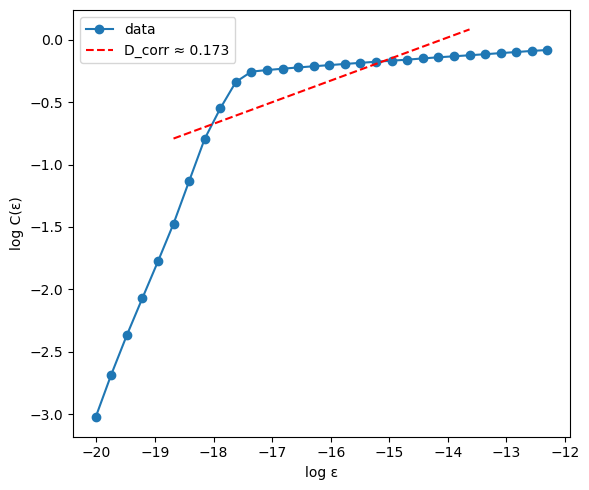

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.spatial.distance import pdist, squareform
from scipy.signal import correlate
import matplotlib.pyplot as plt

# ============================================================
# 1. Spring–slider system (same as Practical 1)
# ============================================================

beta1 = 1.0
beta2 = 0.84
rho = 0.048
kappa_prime = 0.8544
v0 = 1.0

kappa_cr1 = beta1 - 1.0

term_inside_sqrt = (
    4 * rho**2 * (kappa_cr1 + beta2)
    + (kappa_cr1 + rho**2 * (beta2 - 1.0))**2
)
kappa_cr2 = (
    kappa_cr1
    + rho * (2 * beta1 + (beta2 - 1.0) * (2 + rho))
    + np.sqrt(term_inside_sqrt) / (2 * (1 + rho))
)

kappa = kappa_cr2 * kappa_prime

def rhs(t, x):
    x1, x2, x3 = x
    e = np.exp(x1)
    f1 = -kappa*(e - v0) + e*(x1*(beta1-1) + x2 - x3) + rho*e*(beta2*x1 + x3)
    f2 = -kappa*(e - v0)
    f3 = -rho*e*(beta2*x1 + x3)
    return np.array([f1, f2, f3])

# ============================================================
# 2. Integrate system
# ============================================================

def integrate(t_end=4000, dt=0.1, t_transient=400):
    t_eval = np.arange(0, t_end+dt, dt)
    x0 = np.array([0.05, 0, 0])
    sol = solve_ivp(rhs, (0, t_end), x0, t_eval=t_eval, rtol=1e-9, atol=1e-9)
    t = sol.t
    X = sol.y.T
    mask = t >= t_transient
    return t, X, t[mask], X[mask]

t, X, t_attr, X_attr = integrate()

# ============================================================
# 3. Theiler window from first zero of autocorrelation
# ============================================================

def first_zero_autocorr(x):
    x = x - np.mean(x)
    ac = correlate(x, x, mode="full")
    ac = ac[ac.size//2:]
    ac /= ac[0]
    for k in range(1, len(ac)):
        if ac[k] <= 0:
            return k
    return len(ac)-1

W = first_zero_autocorr(X_attr[:,0])
print("Theiler window =", W)

# ============================================================
# 4. Correlation dimension
# ============================================================

def correlation_dimension(X, theiler=None, max_points=4000, n_eps=30):
    N = X.shape[0]
    if N > max_points:
        idx = np.linspace(0, N-1, max_points, dtype=int)
        Y = X[idx]
    else:
        Y = X
    M = Y.shape[0]

    D = squareform(pdist(Y))
    idxs = np.arange(M)
    lag = np.abs(idxs[:,None] - idxs[None,:])

    mask = np.triu(np.ones_like(D, bool), k=1)
    if theiler is not None:
        mask &= (lag > theiler)

    dists = D[mask]
    dists = dists[dists > 0]

    dmin = np.percentile(dists, 5)
    dmax = np.percentile(dists, 95)
    eps = np.logspace(np.log10(dmin), np.log10(dmax), n_eps)

    C = []
    norm = 2/(M*(M-1))
    for e in eps:
        C.append(norm * np.sum(dists < e))
    C = np.array(C)

    log_eps = np.log(eps)
    log_C = np.log(C)

    fit = slice(5, -5)
    slope, intercept = np.polyfit(log_eps[fit], log_C[fit], 1)

    return slope, eps, C, log_eps, log_C

D_corr, eps, C, log_eps, log_C = correlation_dimension(X_attr, theiler=W)
print("Correlation dimension with Theiler window =", D_corr)

D_corr_noW, *_ = correlation_dimension(X_attr, theiler=None)
print("Correlation dimension WITHOUT Theiler window =", D_corr_noW)

# ============================================================
# 5. Plot scaling region
# ============================================================

plt.figure(figsize=(6,5))
plt.plot(log_eps, log_C, "o-", label="data")
fit = slice(5, -5)
slope = D_corr
intercept = np.polyfit(log_eps[fit], log_C[fit], 1)[1]
plt.plot(log_eps[fit], slope*log_eps[fit] + intercept, "r--",
         label=f"D_corr ≈ {slope:.3f}")
plt.xlabel("log ε")
plt.ylabel("log C(ε)")
plt.legend()
plt.tight_layout()
plt.show()

Lyapunov exponents (sorted): [-0.01498814 -0.01501922 -0.07581636]
Kaplan–Yorke dimension D_KY: 0.0


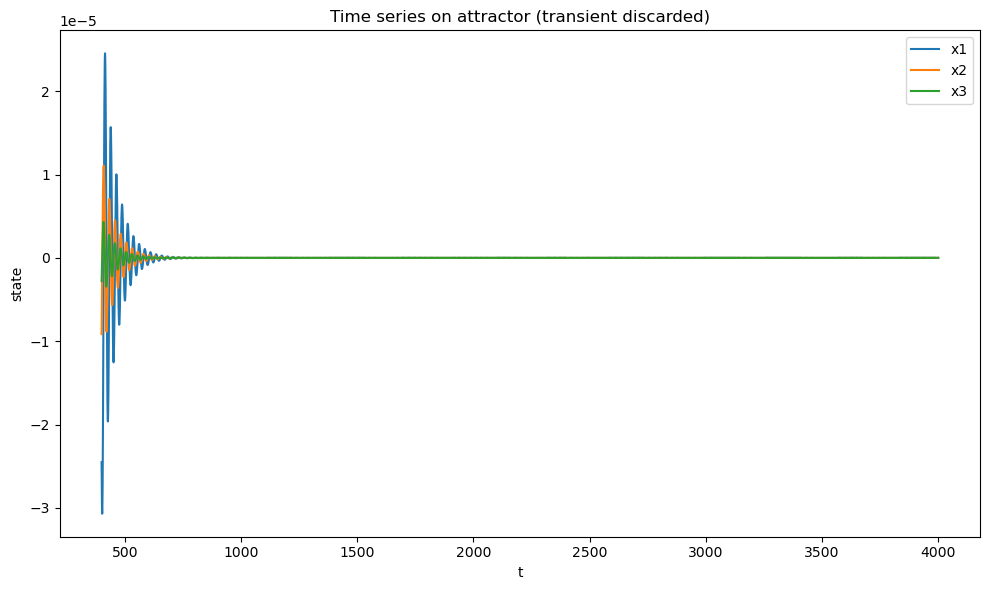

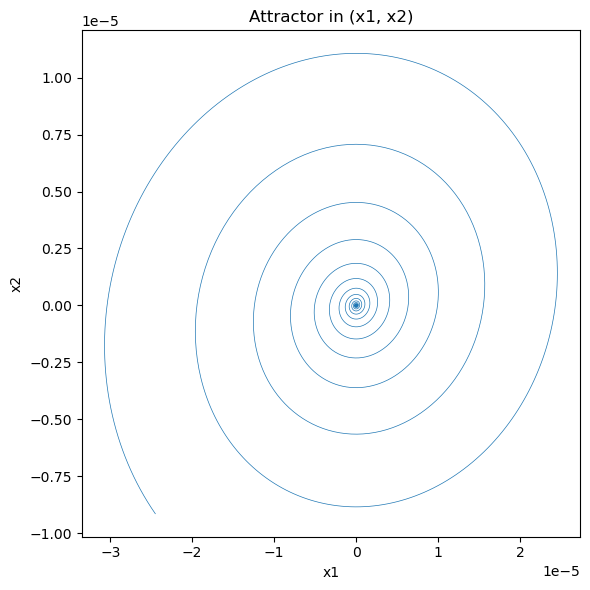

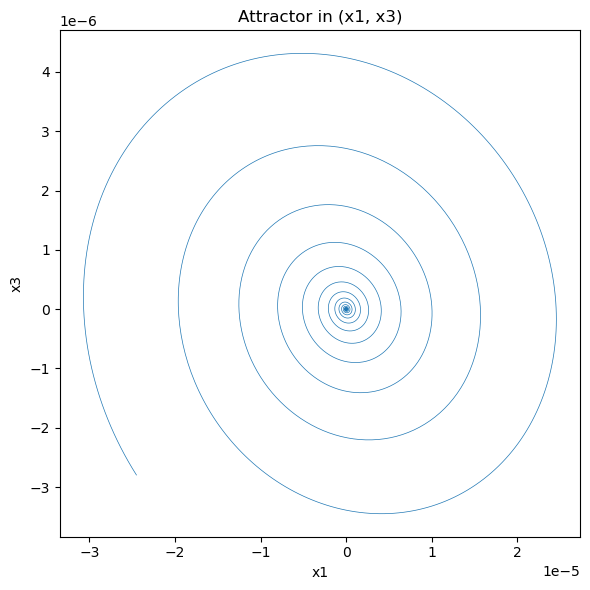

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# Parameters
# ============================================================

beta1 = 1.0
beta2 = 0.84
rho = 0.048
kappa_prime = 0.8544
v0 = 1.0  # adjust if your practical specifies otherwise

# Critical kappas
kappa_cr1 = beta1 - 1.0

term_inside_sqrt = (
    4 * rho**2 * (kappa_cr1 + beta2)
    + (kappa_cr1 + rho**2 * (beta2 - 1.0))**2
)
kappa_cr2 = (
    kappa_cr1
    + rho * (2 * beta1 + (beta2 - 1.0) * (2 + rho))
    + np.sqrt(term_inside_sqrt) / (2 * (1 + rho))
)

kappa = kappa_cr2 * kappa_prime

# ============================================================
# System and Jacobian
# ============================================================

def rhs(t, x):
    x1, x2, x3 = x
    e = np.exp(x1)

    f1 = -kappa * (e - v0) + e * (x1 * (beta1 - 1.0) + x2 - x3) + rho * e * (beta2 * x1 + x3)
    f2 = -kappa * (e - v0)
    f3 = -rho * e * (beta2 * x1 + x3)

    return np.array([f1, f2, f3])

def jacobian(x):
    x1, x2, x3 = x
    e = np.exp(x1)

    df1_dx1 = (
        -kappa * e
        + e * (x1 * (beta1 - 1.0) + x2 - x3 + (beta1 - 1.0))
        + rho * e * (beta2 * x1 + x3 + beta2)
    )
    df1_dx2 = e
    df1_dx3 = e * (-1.0 + rho)

    df2_dx1 = -kappa * e
    df2_dx2 = 0.0
    df2_dx3 = 0.0

    df3_dx1 = -rho * e * (beta2 * x1 + x3 + beta2)
    df3_dx2 = 0.0
    df3_dx3 = -rho * e

    return np.array([
        [df1_dx1, df1_dx2, df1_dx3],
        [df2_dx1, df2_dx2, df2_dx3],
        [df3_dx1, df3_dx2, df3_dx3],
    ])

# ============================================================
# Integrate system
# ============================================================

t_start = 0.0
t_end = 4000.0
dt = 0.1
t_eval = np.arange(t_start, t_end + dt, dt)

x0 = np.array([0.05, 0.0, 0.0])

sol = solve_ivp(
    rhs,
    (t_start, t_end),
    x0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-9,
)

t = sol.t
X = sol.y.T  # shape (N, 3)

# Discard transient
t_transient = 400.0
mask_attr = t >= t_transient
t_attr = t[mask_attr]
X_attr = X[mask_attr]

# ============================================================
# Lyapunov spectrum via QR
# ============================================================

n = 3
N = len(t)
V = np.eye(n)
sum_logs = np.zeros(n)
started = False

for k in range(N - 1):
    xk = X[k]
    J = jacobian(xk)
    A = np.eye(n) + J * dt
    V = A @ V
    Q, R = np.linalg.qr(V)
    V = Q

    if t[k] >= t_transient:
        diag_R = np.diag(R)
        sum_logs += np.log(np.abs(diag_R))
        started = True

if not started:
    raise RuntimeError("Transient too long; no data for Lyapunov calculation.")

T_lyap = t_end - t_transient
lambdas = sum_logs / T_lyap
lambdas_sorted = np.sort(lambdas)[::-1]

def kaplan_yorke_dimension(lams):
    cumsum = np.cumsum(lams)
    j = None
    for i in range(len(lams)):
        if cumsum[i] >= 0:
            j = i
        else:
            break
    if j is None:
        return 0.0
    if j == len(lams) - 1:
        return float(len(lams))
    return j + 1 + cumsum[j] / abs(lams[j + 1])

D_KY = kaplan_yorke_dimension(lambdas_sorted)

print("Lyapunov exponents (sorted):", lambdas_sorted)
print("Kaplan–Yorke dimension D_KY:", D_KY)

# ============================================================
# Plots: time series and attractor
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(t_attr, X_attr[:, 0], label="x1")
plt.plot(t_attr, X_attr[:, 1], label="x2")
plt.plot(t_attr, X_attr[:, 2], label="x3")
plt.xlabel("t")
plt.ylabel("state")
plt.title("Time series on attractor (transient discarded)")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(6, 6))
plt.plot(X_attr[:, 0], X_attr[:, 1], lw=0.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Attractor in (x1, x2)")
plt.tight_layout()

plt.figure(figsize=(6, 6))
plt.plot(X_attr[:, 0], X_attr[:, 2], lw=0.5)
plt.xlabel("x1")
plt.ylabel("x3")
plt.title("Attractor in (x1, x3)")
plt.tight_layout()

plt.show()

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# Parameters
# ============================================================

beta1 = 1.0
beta2 = 0.84
rho = 0.048
kappa_prime = 0.8544
v0 = 1.0

# Critical kappas
kappa_cr1 = beta1 - 1.0

term_inside_sqrt = (
    4 * rho**2 * (kappa_cr1 + beta2)
    + (kappa_cr1 + rho**2 * (beta2 - 1.0))**2
)
kappa_cr2 = (
    kappa_cr1
    + rho * (2 * beta1 + (beta2 - 1.0) * (2 + rho))
    + np.sqrt(term_inside_sqrt) / (2 * (1 + rho))
)

kappa = kappa_cr2 * kappa_prime

# ============================================================
# System and Jacobian
# ============================================================

def rhs(t, x):
    x1, x2, x3 = x
    e = np.exp(x1)

    f1 = -kappa*(e - v0) + e*(x1*(beta1-1) + x2 - x3) + rho*e*(beta2*x1 + x3)
    f2 = -kappa*(e - v0)
    f3 = -rho*e*(beta2*x1 + x3)

    return np.array([f1, f2, f3])

def jacobian(x):
    x1, x2, x3 = x
    e = np.exp(x1)

    df1_dx1 = (
        -kappa * e
        + e * (x1*(beta1 - 1) + x2 - x3 + (beta1 - 1))
        + rho * e * (beta2*x1 + x3 + beta2)
    )
    df1_dx2 = e
    df1_dx3 = e * (-1 + rho)

    df2_dx1 = -kappa * e
    df2_dx2 = 0.0
    df2_dx3 = 0.0

    df3_dx1 = -rho * e * (beta2*x1 + x3 + beta2)
    df3_dx2 = 0.0
    df3_dx3 = -rho * e

    return np.array([
        [df1_dx1, df1_dx2, df1_dx3],
        [df2_dx1, df2_dx2, df2_dx3],
        [df3_dx1, df3_dx2, df3_dx3],
    ])

# ============================================================
# Integrate system
# ============================================================

t_start = 0.0
t_end = 4000.0
dt = 0.1
t_eval = np.arange(t_start, t_end + dt, dt)

x0 = np.array([0.05, 0.0, 0.0])

sol = solve_ivp(
    rhs,
    (t_start, t_end),
    x0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-9,
)

t = sol.t
X = sol.y.T

# Discard transient
t_transient = 400.0
mask_attr = t >= t_transient
t_attr = t[mask_attr]
X_attr = X[mask_attr]

# ============================================================
# Lyapunov spectrum via QR
# ============================================================

n = 3
N = len(t)
V = np.eye(n)
sum_logs = np.zeros(n)
started = False

for k in range(N - 1):
    J = jacobian(X[k])
    A = np.eye(n) + J * dt
    V = A @ V
    Q, R = np.linalg.qr(V)
    V = Q

    if t[k] >= t_transient:
        sum_logs += np.log(np.abs(np.diag(R)))
        started = True

if not started:
    raise RuntimeError("Transient too long; no Lyapunov data.")

T = t_end - t_transient
lambdas = sum_logs / T
lambdas_sorted = np.sort(lambdas)[::-1]


In [8]:
lambdas

array([-0.01501922, -0.01498814, -0.07581636])

In [11]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# Parameters
# ============================================================

beta1 = 1.0
beta2 = 0.84
rho = 0.048
kappa_prime = 0.8544
v0 = 1.0

kappa_cr1 = beta1 - 1.0

term_inside_sqrt = (
    4 * rho**2 * (kappa_cr1 + beta2)
    + (kappa_cr1 + rho**2 * (beta2 - 1.0))**2
)
kappa_cr2 = (
    kappa_cr1
    + rho * (2 * beta1 + (beta2 - 1.0) * (2 + rho))
    + np.sqrt(term_inside_sqrt) / (2 * (1 + rho))
)

kappa = kappa_cr2 * kappa_prime

# ============================================================
# System and Jacobian
# ============================================================

def rhs(t, x):
    x1, x2, x3 = x
    e = np.exp(x1)

    f1 = -kappa*(e - v0) + e*(x1*(beta1-1) + x2 - x3) + rho*e*(beta2*x1 + x3)
    f2 = -kappa*(e - v0)
    f3 = -rho*e*(beta2*x1 + x3)

    return np.array([f1, f2, f3])

def jacobian(x):
    x1, x2, x3 = x
    e = np.exp(x1)

    df1_dx1 = (
        -kappa * e
        + e * (x1*(beta1 - 1) + x2 - x3 + (beta1 - 1))
        + rho * e * (beta2*x1 + x3 + beta2)
    )
    df1_dx2 = e
    df1_dx3 = e * (-1 + rho)

    df2_dx1 = -kappa * e
    df2_dx2 = 0.0
    df2_dx3 = 0.0

    df3_dx1 = -rho * e * (beta2*x1 + x3 + beta2)
    df3_dx2 = 0.0
    df3_dx3 = -rho * e

    return np.array([
        [df1_dx1, df1_dx2, df1_dx3],
        [df2_dx1, df2_dx2, df2_dx3],
        [df3_dx1, df3_dx2, df3_dx3],
    ])

# ============================================================
# Integrate system
# ============================================================

t_start = 0.0
t_end = 4000.0
dt = 0.1
t_eval = np.arange(t_start, t_end + dt, dt)

x0 = np.array([0.05, 0.0, 0.0])

sol = solve_ivp(
    rhs,
    (t_start, t_end),
    x0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-10,
    atol=1e-12,
)

t = sol.t
X = sol.y.T

# ============================================================
# Remove transient
# ============================================================

t_transient = 400.0
mask = t >= t_transient
t_attr = t[mask]
X_attr = X[mask]

# ============================================================
# Lyapunov spectrum via QR
# ============================================================

n = 3
V = np.eye(n)
sum_logs = np.zeros(n)

for k in range(len(t) - 1):
    J = jacobian(X[k])          # <-- MUST use X[k], not X_attr
    A = np.eye(n) + J * dt      # <-- MUST use dt, not solver step
    V = A @ V
    Q, R = np.linalg.qr(V)
    V = Q

    if t[k] >= t_transient:
        sum_logs += np.log(np.abs(np.diag(R)))

T = t_end - t_transient
lambdas = sum_logs / T
lambdas_sorted = np.sort(lambdas)[::-1]

print(lambdas)

def kaplan_yorke(lams):
    c = np.cumsum(lams)
    j = np.where(c >= 0)[0][-1]
    return j + 1 + c[j] / abs(lams[j+1])

D_KY = kaplan_yorke(lambdas_sorted)

print("Lyapunov exponents:", lambdas_sorted)
print("Kaplan–Yorke dimension:", D_KY)

[-0.01501922 -0.01498814 -0.07581636]


IndexError: index -1 is out of bounds for axis 0 with size 0